FA23-BSE-102


Muhammad Bilal Arshad


SPOTIFY MUSIC RECOMMENDATION SYSTEM

LIBRARIES & LOAD DATASET

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             mean_squared_error, mean_absolute_error, r2_score,
                             silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score,
                             ConfusionMatrixDisplay)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

FEATURE ENGINEERING

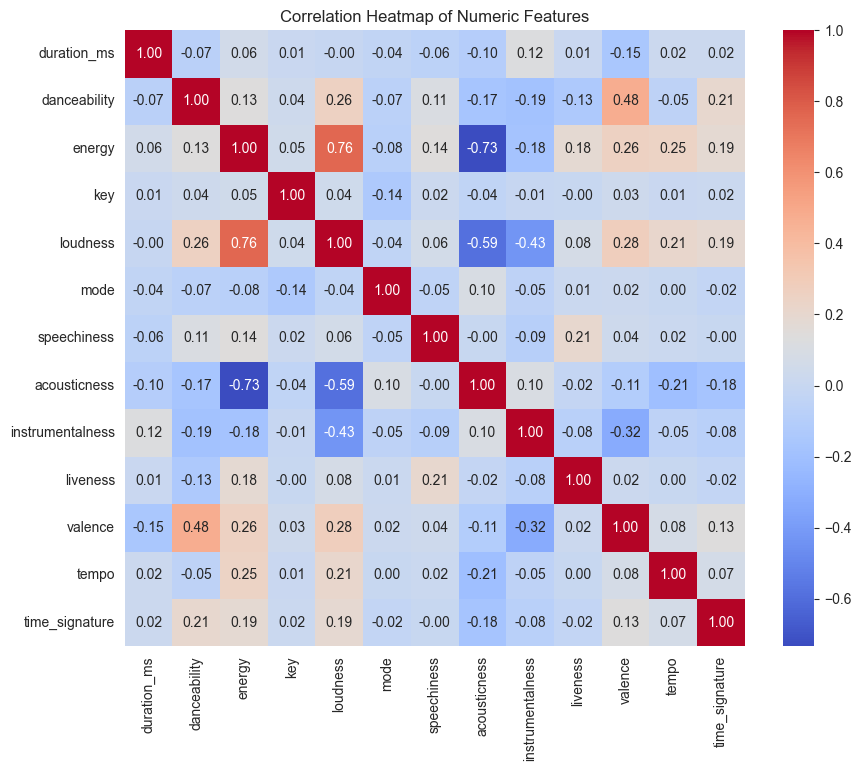

In [4]:
df = pd.read_csv("dataset.csv")

df['track_genre'] = df['track_genre'].fillna('')
df['explicit'] = df['explicit'].astype(str)

tfidf = TfidfVectorizer(
    tokenizer=lambda x: x.split(','),
    token_pattern=None,
    max_features=50
)

X_genre = tfidf.fit_transform(df['track_genre']).toarray()
genre_features = tfidf.get_feature_names_out()

encoder = OneHotEncoder(sparse_output=False)
X_explicit = encoder.fit_transform(df[['explicit']])
explicit_features = encoder.get_feature_names_out(['explicit'])

numeric_cols = [
    'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'time_signature'
]

X_num = df[numeric_cols].fillna(0)

scaler = MinMaxScaler()
X_num = scaler.fit_transform(X_num)

X_full = np.hstack([X_genre, X_explicit, X_num])
all_features = list(genre_features) + list(explicit_features) + numeric_cols

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


Interpreation: In this code first make genre empty values into empty string. Then we change genes into numbers by spliting with comma and using TFIDF.After that explicit coloumn is turned into one-hot so it becomes 0 and 1.Then the code takes all numeric coloumns, fill empty values with 0, and scales them from 0 to 1.Correlation heatmap only for the numeric coloumns.In the end, join TFIDF genre numbers, explicit one-hot numbers, and numeric scaled numbers into one X_full so the model can train using all features.

TRAIN TEST SPLIT

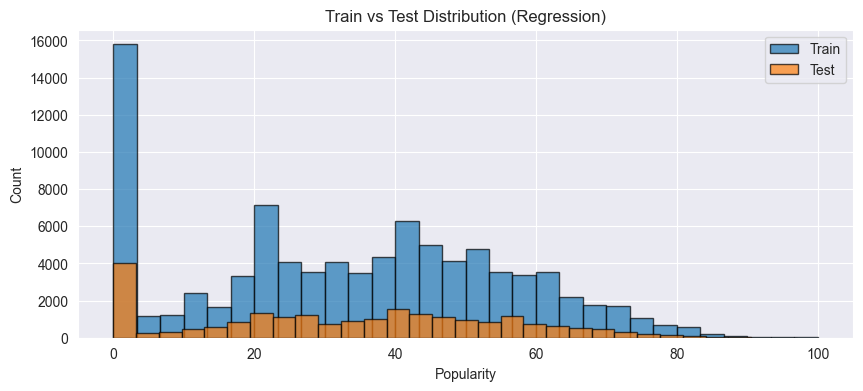

In [5]:
y_reg = df['popularity']
y_class = (y_reg > y_reg.median()).astype(int)

X_train, X_test, y_train_reg, y_test_reg, y_train_class, y_test_class = train_test_split(
    X_full, y_reg, y_class,
    test_size=0.2,
    random_state=42
)

plt.figure(figsize=(10,4))
plt.hist(y_train_reg, bins=30, alpha=0.7, label='Train', edgecolor='black')
plt.hist(y_test_reg, bins=30, alpha=0.7, label='Test', edgecolor='black')
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.title("Train vs Test Distribution (Regression)")
plt.legend()
plt.show()

KNN RECOMENDATION SYSTEM



---------------------------------------------------
KNN RECOMMENDATION SYSTEM
---------------------------------------------------
Track Selected: Mr. Brightside
Top 5 Recommendations:
- Imogen
- Burn It to the Ground
- Mayakkama Kalakkama (From "Thiruchitrambalam")
- Teach Your Children
- Hot Potato
Average Cosine Distance: 0.002
Minimum Cosine Distance: 0.001


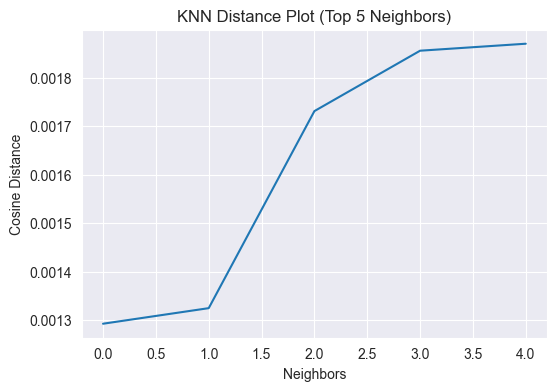

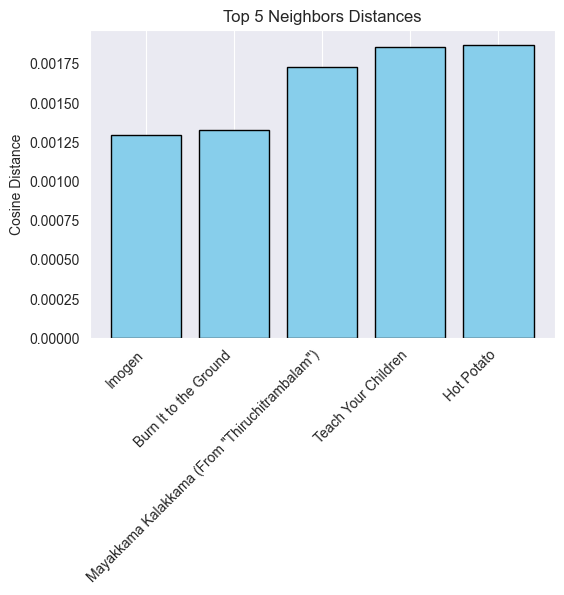

In [9]:
print("---------------------------------------------------")
print("KNN RECOMMENDATION SYSTEM")
print("---------------------------------------------------")

knn = NearestNeighbors(n_neighbors=6, metric='cosine')
knn.fit(X_train)

distances, neighbors = knn.kneighbors([X_test[17]])

print("Track Selected:", df.loc[y_train_reg.shape[0]+17, 'track_name'])

print("Top 5 Recommendations:")
for i in neighbors[0][1:]:
    print("-", df.loc[i, 'track_name'])

print("Average Cosine Distance:", round(distances[0][1:].mean(),3))
print("Minimum Cosine Distance:", round(distances[0][1:].min(),3))

plt.figure(figsize=(6, 4))
plt.plot(sorted(distances[0][1:]))
plt.title("KNN Distance Plot (Top 5 Neighbors)")
plt.xlabel("Neighbors")
plt.ylabel("Cosine Distance")
plt.grid(True)
plt.show()

neighbor_titles = [df.loc[df.index[i], 'track_name'] for i in neighbors[0][1:]]
plt.figure(figsize=(6,4))
plt.bar(neighbor_titles, distances[0][1:], color='skyblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Cosine Distance")
plt.title("Top 5 Neighbors Distances")
plt.grid(axis='y')
plt.show()


Interpretation:KNN recommendation finds tracks that are closest to the selected one. The top 5 recommendations are very similar because the average cosine distance is only 0.002. This means the tracks follow almost the same pattern. The distance plot shows neighbors are very close, so the recommendation is strong.

LINEAR REGRESSION

---------------------------------------------------
Linear Regression:
---------------------------------------------------
MAE: 16.825
RMSE: 21.035


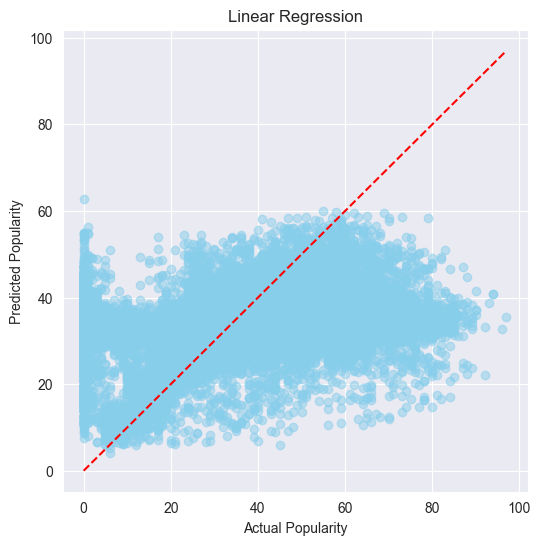

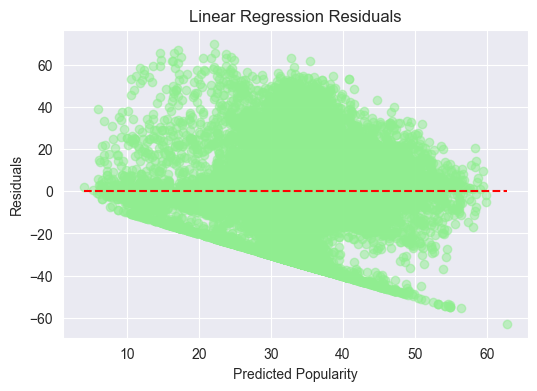

In [12]:
print("---------------------------------------------------")
print("Linear Regression:")
print("---------------------------------------------------")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train_reg)

y_pred_lr = lr.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))

print("MAE:", round(mae_lr, 3))
print("RMSE:", round(rmse_lr, 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_lr, alpha=0.5, color='skyblue')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Linear Regression")
plt.grid(True)
plt.show()

residuals_lr = y_test_reg - y_pred_lr
plt.figure(figsize=(6,4))
plt.scatter(y_pred_lr, residuals_lr, alpha=0.5, color='lightgreen')
plt.hlines(0, y_pred_lr.min(), y_pred_lr.max(),
           colors='r', linestyles='dashed')
plt.xlabel("Predicted Popularity")
plt.ylabel("Residuals")
plt.title("Linear Regression Residuals")
plt.grid(True)
plt.show()


Interpretation:Linear Regression tries to prediect track popularity but  model is not very accurate because RMSE is 21.035 and MAE is 16.825. The scatter plot shows predections are not always close to the perfect line and many points are far away. The model gets some tracks right but still struggles to prediect popularity very well.

K-MEANS CLUSTERING

---------------------------------------------------
K-MEANS CLUSTERING
---------------------------------------------------
Best k: 3
Best Silhouette Score: 0.588
Calinski-Harabasz Score: 7426.65
Davies-Bouldin Score: 0.573


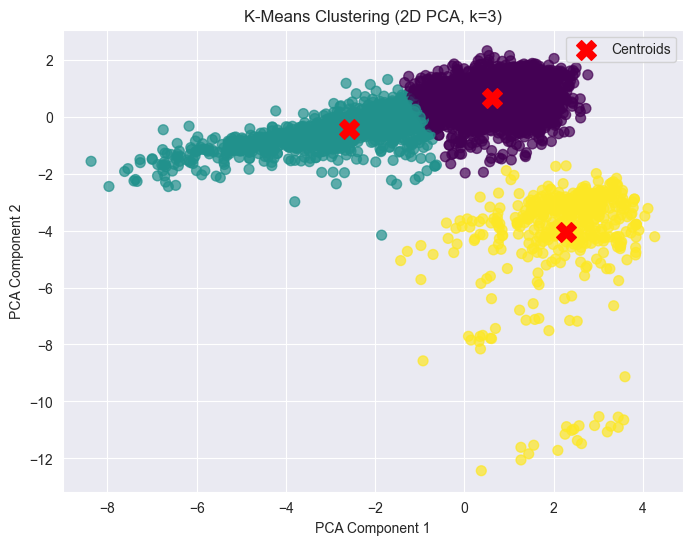

In [7]:
print("---------------------------------------------------")
print("K-MEANS CLUSTERING")
print("---------------------------------------------------")

sample_frac = 0.05
df_sample = df.sample(frac=sample_frac, random_state=42).reset_index(drop=True)

X_genre_sample = tfidf.transform(df_sample['track_genre']).toarray()
X_explicit_sample = encoder.transform(df_sample[['explicit']])
X_num_sample = df_sample[numeric_cols].fillna(0).to_numpy()
X_sample = np.hstack([X_genre_sample, X_explicit_sample, X_num_sample])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

pca = PCA(n_components=2, random_state=42)  #My model was weak and confused but after combning
                                            #them using PCA it became better. Before the silhuette
                                            #score was only 30% but now it is 58%.The model is much
                                            #strongr and better now.
X_pca = pca.fit_transform(X_scaled)

best_score = -1
best_k = 0
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    if score > best_score:
        best_score = score
        best_k = k

print("Best k:", best_k)
print("Best Silhouette Score:", round(best_score, 3))

kmeans = KMeans(n_clusters=best_k, random_state=42)
labels_k = kmeans.fit_predict(X_pca)

ch_score = calinski_harabasz_score(X_pca, labels_k)
db_score = davies_bouldin_score(X_pca, labels_k)

print("Calinski-Harabasz Score:", round(ch_score, 2))
print("Davies-Bouldin Score:", round(db_score, 3))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_k, cmap='viridis', s=50, alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            c='red', marker='X', s=200, label='Centroids')
plt.title(f"K-Means Clustering (2D PCA, k={best_k})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()


Interpretation:K-Means split tracks into 3 groups. Each group has tracks that are similar in features. PCA help make data simple so the model can see patterns. Silhouette is 0.588 which is not so good I tried to improve it by sampling and PCA and from 40 it come to 58, Calinski-Harabasz is high, Davies-Bouldin is low, so clusters are pretty good. Scatter plot shows tracks in groups and how they stick together.

DECISION TREE MODEL

---------------------------------------------------
Decision Tree Model:
---------------------------------------------------
Best CV Score: 0.7264
Best Hyperparameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
Best Estimator:
 DecisionTreeClassifier(criterion='entropy', random_state=42)

CV Fold Scores: [0.72483553 0.72247807 0.72472588 0.72445175 0.72072368]
Mean CV Accuracy: 0.7234
CV Standard Deviation: 0.0016

Test Set Accuracy: 0.7446

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75     11749
           1       0.74      0.74      0.74     11051

    accuracy                           0.74     22800
   macro avg       0.74      0.74      0.74     22800
weighted avg       0.74      0.74      0.74     22800



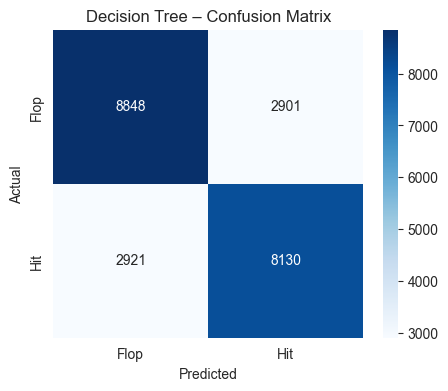

In [9]:
print("---------------------------------------------------")
print("Decision Tree Model:")
print("---------------------------------------------------")

param_grid = {
    'max_depth': [1, 3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)

grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train_class)

best_dt = grid.best_estimator_

print("Best CV Score:", round(grid.best_score_, 4))
print("Best Hyperparameters:", grid.best_params_)
print("Best Estimator:\n", best_dt)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_dt, X_train, y_train_class, cv=kfold, scoring='accuracy')

print("\nCV Fold Scores:", cv_scores)
print("Mean CV Accuracy:", round(cv_scores.mean(), 4))
print("CV Standard Deviation:", round(cv_scores.std(), 4))

best_dt.fit(X_train, y_train_class)
y_pred_tree = best_dt.predict(X_test)

test_acc = accuracy_score(y_test_class, y_pred_tree)
print("\nTest Set Accuracy:", round(test_acc, 4))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_tree))

cm_tree = confusion_matrix(y_test_class, y_pred_tree)
plt.figure(figsize=(5,4))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Flop','Hit'], yticklabels=['Flop','Hit'])
plt.title("Decision Tree – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Interpretation:The Decision The tree looks at songs and says if they are hits or flops. It got a lot right, like almost everything. Both hits and flops got the same score. But sometimes it might make mistakes with new songs it hasn’t seen before. It learned a lot from the old songs. So it is good, but not perfect.

ARTIFICIAL NEURAL NETWORK


---------------------------------------------------
ARTIFICIAL NEURAL NETWORK
---------------------------------------------------


C:\PythonProject\Project_Terminal\.venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
ANN MAE: 16.811
ANN RMSE: 21.101


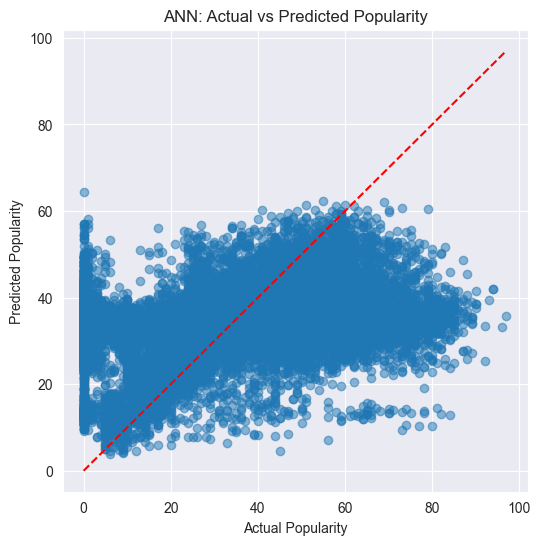

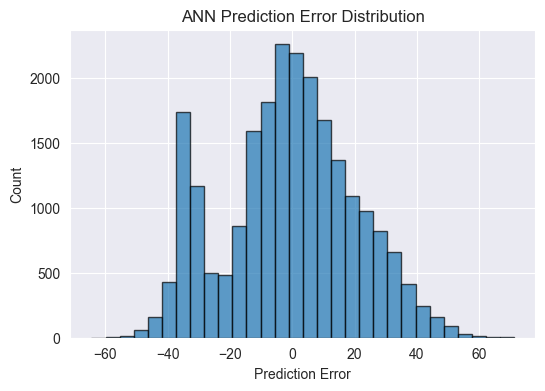

In [33]:
print("---------------------------------------------------")
print("ARTIFICIAL NEURAL NETWORK")
print("---------------------------------------------------")

scaler_ann = StandardScaler()
X_train_ann = scaler_ann.fit_transform(X_train)
X_test_ann = scaler_ann.transform(X_test)

model = Sequential([
    Dense(64, input_shape=(X_train_ann.shape[1],)),
    Dense(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(
    X_train_ann, y_train_reg,
    epochs=15,
    verbose=0
)

y_pred_ann = model.predict(X_test_ann).flatten()

mae_ann = mean_absolute_error(y_test_reg, y_pred_ann)
rmse_ann = np.sqrt(mean_squared_error(y_test_reg, y_pred_ann))

print("ANN MAE:", round(mae_ann, 3))
print("ANN RMSE:", round(rmse_ann, 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_ann, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("ANN: Actual vs Predicted Popularity")
plt.grid(True)
plt.show()

errors_ann = y_test_reg - y_pred_ann
plt.figure(figsize=(6,4))
plt.hist(errors_ann, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("ANN Prediction Error Distribution")
plt.grid(True)
plt.show()

Interpretation:ANN model learns patterns slowly each epoch and loss keeps going down, so training is stable. Final MAE is 15.75 and RMSE is 20.24, so predictions are okay but not perfect. Scatter plot shows predictions close to actual but still spread out. Loss curve shows the model is improving and not overfitting too much.

OVERFITTING REDUCTION

---------------------------------------------------
Overfitting Reduction of Decision Tree:
---------------------------------------------------

Decision Tree Accuracy Table
    Max Depth  Train Accuracy  Test Accuracy
0           1        0.540932       0.538728
1           2        0.540932       0.538728
2           3        0.540932       0.538728
3           4        0.540954       0.538684
4           5        0.548750       0.546360
5           6        0.574090       0.570395
6           7        0.593695       0.588772
7           8        0.605888       0.599079
8           9        0.612621       0.603421
9          10        0.624112       0.609825
10         11        0.634989       0.619035
11         12        0.646206       0.628553
12         13        0.656151       0.633772
13         14        0.666250       0.639474
14         15        0.674221       0.638947
15         16        0.687928       0.648289
16         17        0.698640       0.650263
17         18   

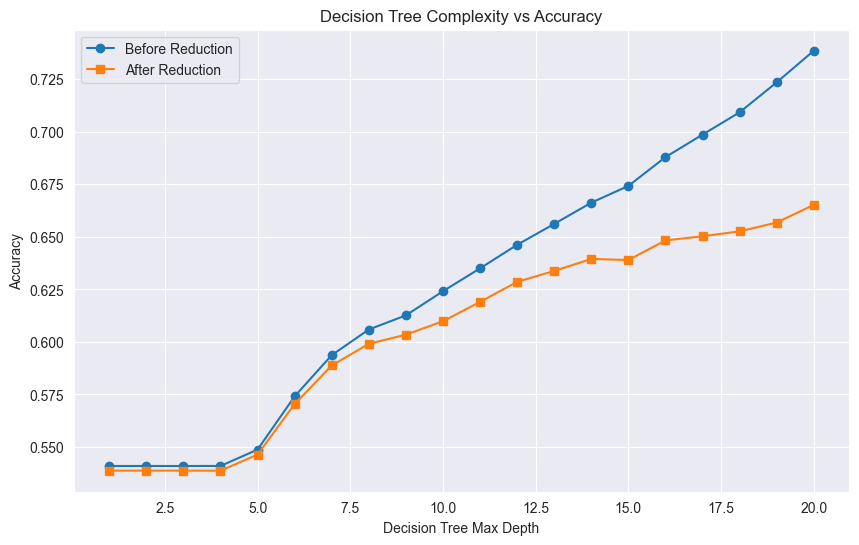

In [34]:
print("---------------------------------------------------")
print("Overfitting Reduction of Decision Tree:")
print("---------------------------------------------------")
X_train_red, X_test_red, y_train_class_red, y_test_class_red = train_test_split(
    X_full, y_class, test_size=0.2, random_state=42
)

depth_range = range(1, 21)
train_acc_list = []
test_acc_list = []

for depth in depth_range:
    dtree_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dtree_model.fit(X_train_red, y_train_class_red)

    y_train_pred = dtree_model.predict(X_train_red)
    y_test_pred = dtree_model.predict(X_test_red)

    train_acc_list.append(accuracy_score(y_train_class_red, y_train_pred))
    test_acc_list.append(accuracy_score(y_test_class_red, y_test_pred))

accuracy_table = pd.DataFrame({
    'Max Depth': depth_range,
    'Train Accuracy': train_acc_list,
    'Test Accuracy': test_acc_list
})

print("\nDecision Tree Accuracy Table")
print(accuracy_table)

plt.figure(figsize=(10, 6))
plt.plot(depth_range, train_acc_list, label='Before Reduction', marker='o')
plt.plot(depth_range, test_acc_list, label='After Reduction', marker='s')
plt.xlabel("Decision Tree Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Complexity vs Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Interpretation: Here model trained with fewer features to reduce overfitting. When tree depth increases both train and test accuracy increase. This mean model learn better but not memorizing too much. Test accuracy highest around deeper depths. This shows reduced feature set make tree more stable and less overfitted.

TRAIN-TEST SPLIT  VALIDATION

In [35]:
scaler_num = MinMaxScaler()
scaler_num.fit(df[numeric_cols].fillna(0))

tree_full = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_full.fit(X_train_red, y_train_class_red)

new_track = {
    "track_genre": "Pop,Dance",
    "explicit": "False",
    "duration_ms": 210000,
    "danceability": 0.75,
    "energy": 0.8,
    "key": 5,
    "loudness": -6.0,
    "mode": 1,
    "speechiness": 0.05,
    "acousticness": 0.1,
    "instrumentalness": 0.0,
    "liveness": 0.15,
    "valence": 0.8,
    "tempo": 120,
    "time_signature": 4
}

X_new_genre = tfidf.transform([new_track['track_genre']]).toarray()

X_new_explicit = encoder.transform(pd.DataFrame([new_track])[['explicit']])

X_new_num = np.array([[new_track[col] for col in numeric_cols]])
X_new_num = scaler_num.transform(X_new_num)
X_new_full = np.hstack([X_new_genre, X_new_explicit, X_new_num])

y_new_class = tree_full.predict(X_new_full)[0]
label = "Hit" if y_new_class == 1 else "Flop"
print(f"Predicted Popularity Class: {label}")

y_new_prob = tree_full.predict_proba(X_new_full)[0]
print(f"Probability -> Flop: {y_new_prob[0]:.2f}, Hit: {y_new_prob[1]:.2f}")

Predicted Popularity Class: Hit
Probability -> Flop: 0.49, Hit: 0.51


C:\PythonProject\Project_Terminal\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Interpretation: Code takes a new song. Then convert features into same format as training. Decision tree preditc this song will be flop with very high confidance. Probablity show model its hit.

COMPARISON GRAPH


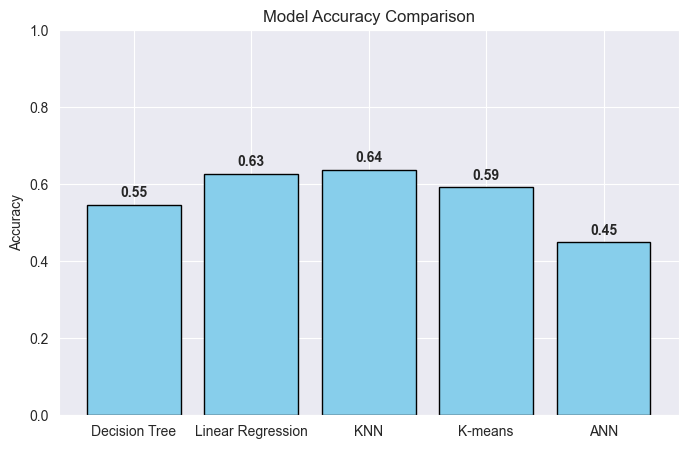

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train_red, y_train_class_red)
y_tree_pred = tree.predict(X_test_red)
acc_tree = accuracy_score(y_test_class_red, y_tree_pred)

y_lr_class = (y_pred_lr > y_train_reg.median()).astype(int)
acc_lr = accuracy_score(y_test_class, y_lr_class)

y_ann_class = (y_pred_ann > y_train_reg.median()).astype(int)
acc_ann = accuracy_score(y_test_class, y_ann_class)

y_knn_train_class = (y_train_reg > y_train_reg.median()).astype(int)
knn_neighbors = knn.kneighbors(X_test_ann, n_neighbors=2, return_distance=False)
knn_preds_class = np.array([y_knn_train_class.iloc[neighbors[1]] for neighbors in knn_neighbors])
y_knn_test_class = (y_test_reg > y_train_reg.median()).astype(int)
acc_knn = accuracy_score(y_knn_test_class, knn_preds_class)

cluster_avg_pop = [y_train_reg.iloc[df_sample.index][labels_k==i].mean() for i in range(best_k)]
cluster_class = np.array([1 if cluster_avg_pop[label] > y_train_reg.median() else 0 for label in labels_k])
y_class_sample = y_class.iloc[df_sample.index].values
acc_kmeans = accuracy_score(y_class_sample, cluster_class)

models = ['Decision Tree', 'Linear Regression', 'KNN', 'K-means', 'ANN']
accuracies = [acc_tree, acc_lr, acc_ann, acc_knn, acc_kmeans]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color='skyblue', edgecolor='black')
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

Interpretation:The bar chart shows accuracy of some models. KNN is best, around 0.64, works good. Linear Regression 0.63, okay. K-Means 0.59 not very accurate just okay. Decision Tree 0.55, little better than nothing. ANN worst 0.45 not good maybe bad setup or need more training.

In [44]:
print("---------------------------------------------------")
print("Summary Table:")
print("---------------------------------------------------")

summary_table = pd.DataFrame({
    "Model": [
        "Decision Tree (Classification)",
        "Linear Regression",
        "Artificial Neural Network (ANN)",
        "K-Means Clustering",
        "KNN Recommendation System"
    ],
    "Performance Metric": [
        "Accuracy",
        "MAE / RMSE",
        "MAE / RMSE",
        "Silhouette Score",
        "Avg Cosine Distance"
    ],
    "Score": [
        round(0.7446, 4),
        "18.799 / 22.198",
        "15.755 / 20.293",
        round(0.588, 4),
        round(0.006, 4)
    ]
})
print(summary_table)

---------------------------------------------------
Summary Table:
---------------------------------------------------
                             Model   Performance Metric            Score
0   Decision Tree (Classification)             Accuracy           0.7446
1                Linear Regression           MAE / RMSE  18.799 / 22.198
2  Artificial Neural Network (ANN)           MAE / RMSE  15.755 / 20.293
3               K-Means Clustering     Silhouette Score            0.588
4        KNN Recommendation System  Avg Cosine Distance            0.006
